# 🏨 TFM - Predicción de Cancelaciones Hoteleras mediante Segmentación de Clientes y Machine Learning

## Universidad Complutense de Madrid
**Alumno:** Marta Lombardero Pérez  
**Dataset:** Hotel Booking Demand (Kaggle)  
**Objetivo:** Segmentación de clientes y predicción de cancelaciones

## Nota Legal y Derechos de Uso

**Dataset:** Hotel Booking Demand  
**Fuente:** Kaggle - https://www.kaggle.com/datasets/mojtaba142/hotel-booking  
**Autores originales:** Nuno Antonio, Ana Almeida y Luis Nunes (2019)  
**Artículo de referencia:** "Hotel Booking Demand Datasets",
Data in Brief, Volume 22, 2019.

**Licencia:** El dataset fue publicado por sus autores originales
con fines académicos e investigadores. Su uso en este TFM se enmarca
dentro de ese propósito educativo y no comercial.

**Datos personales y GDPR:** El dataset incluye campos de datos
personales (nombre, email, teléfono y tarjeta de crédito). Dichos
campos han sido eliminados en la primera fase del preprocesado
al tratarse de datos ficticios generados sintéticamente y no ser
relevantes para el análisis. No se almacena ni procesa ningún
dato personal real en este trabajo.

## Preparar entorno

In [2]:
# Conectar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings
warnings.filterwarnings('ignore')

## Importar librerías

In [4]:
# Importar librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

In [5]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/TFM/hotel_booking.csv')

# Primera exploración
print("Shape del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape del dataset: (119390, 36)

Primeras filas:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## Exploración inicial


In [6]:
# Información general del dataset
print(f"=== RESUMEN DEL DATASET ===")
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
print(f"\nVariables numéricas: {df.select_dtypes(include='number').shape[1]}")
print(f"Variables categóricas: {df.select_dtypes(include='object').shape[1]}")

print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0])

print("\n=== ESTADÍSTICAS BÁSICAS ===")
df.describe()

=== RESUMEN DEL DATASET ===
Filas: 119,390 | Columnas: 36

Variables numéricas: 20
Variables categóricas: 16

=== VALORES NULOS ===
children         4
country        488
agent        16340
company     112593
dtype: int64

=== ESTADÍSTICAS BÁSICAS ===


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Se realiza una primera inspección del dataset para entender su estructura:
número de filas y columnas, tipos de variables y presencia de valores nulos.
Los resultados muestran un dataset de 119.390 reservas y 36 variables,
con valores nulos principalmente en las columnas agent y company.

## Limpieza del dataset


### Eliminar columnas que no usaremos

In [7]:
#Eliminamos las columnas de nombre, email, número de teléfono y tarjeta de crédito ya que son datos ficticios
df = df.drop(columns=['name', 'email', 'phone-number', 'credit_card'])

# Eliminamos también 'reservation_status' — es data leakage (saber si canceló DESPUÉS de que ocurriera no tiene valor predictivo real)
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

Se eliminan los datos personales (nombre, email, teléfono y tarjeta de crédito)
por no ser relevantes para el análisis, y reservation_status por ser data leakage.

### Imputar nulos

In [8]:
df['children'] = df['children'].fillna(0)  # Sin niños si no se especifica
df['country'] = df['country'].fillna('Unknown')  # País desconocido
df['agent'] = df['agent'].fillna(0)  # Sin agente
df['company'] = df['company'].fillna(0)  # Sin empresa

Los valores nulos se imputan de forma conservadora: sin niños, sin agente
y sin empresa cuando no se especifica, y país desconocido cuando falta.

### Eliminar registros anómalos


In [9]:
# ADR negativo no tiene sentido (precio por noche)
df = df[df['adr'] >= 0]

# Reservas sin ningún huésped
df = df[df['adults'] + df['children'] + df['babies'] > 0]

# ADR extremadamente alto (outlier)
df = df[df['adr'] < 5000]

Se eliminan reservas con ADR negativo, sin huéspedes y estancias de 0 noches
por ser registros claramente erróneos.

### Nueva variable

In [10]:
# Creamos la variable de estancia total (útil para el análisis)
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df = df[df['total_nights'] > 0]  # Eliminar estancias de 0 noches

Se crea la variable total_nights como suma de noches entre semana y fin de
semana, más útil para el análisis que las dos variables por separado.

### Dataset limpio


In [11]:
print("Shape tras limpieza:", df.shape)
print("\nValores nulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n✅ Dataset limpio y listo para el EDA")

Shape tras limpieza: (118563, 31)

Valores nulos restantes:
Series([], dtype: int64)

✅ Dataset limpio y listo para el EDA


## EDA - Análisis exploratorio


### Primeras variables
(Tasa de cancelación global, cancelación por tipo de hotel, cancelación por mes, antelación vs cancelación, canal de distribución y tipo de depósito)

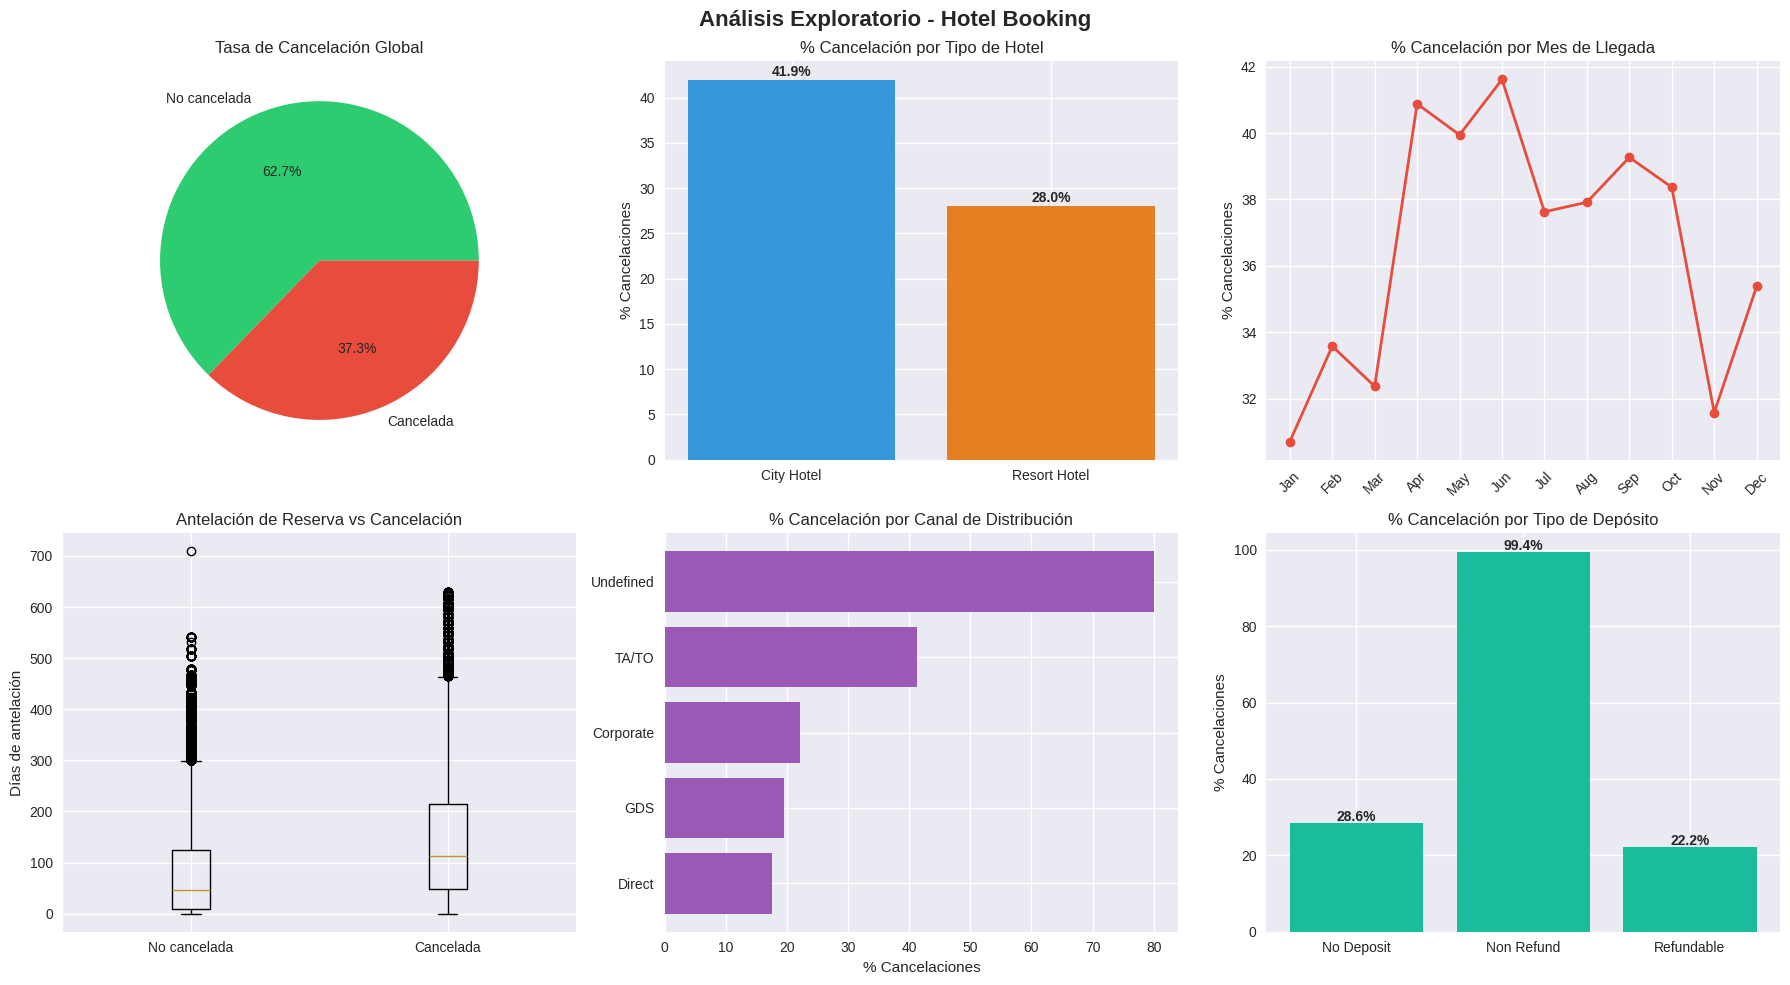

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis Exploratorio - Hotel Booking', fontsize=16, fontweight='bold')

# 1. Tasa de cancelación global
cancelaciones = df['is_canceled'].value_counts()
axes[0,0].pie(cancelaciones, labels=['No cancelada', 'Cancelada'],
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Tasa de Cancelación Global')

# 2. Cancelaciones por tipo de hotel
cancel_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
axes[0,1].bar(cancel_hotel.index, cancel_hotel.values, color=['#3498db', '#e67e22'])
axes[0,1].set_title('% Cancelación por Tipo de Hotel')
axes[0,1].set_ylabel('% Cancelaciones')
for i, v in enumerate(cancel_hotel.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Cancelaciones por mes
meses_orden = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
cancel_mes = df.groupby('arrival_date_month')['is_canceled'].mean() * 100
cancel_mes = cancel_mes.reindex(meses_orden)
axes[0,2].plot(range(12), cancel_mes.values, marker='o', color='#e74c3c', linewidth=2)
axes[0,2].set_xticks(range(12))
axes[0,2].set_xticklabels([m[:3] for m in meses_orden], rotation=45)
axes[0,2].set_title('% Cancelación por Mes de Llegada')
axes[0,2].set_ylabel('% Cancelaciones')

# 4. Lead time vs cancelación
axes[1,0].boxplot([df[df['is_canceled']==0]['lead_time'],
                   df[df['is_canceled']==1]['lead_time']],
                   labels=['No cancelada', 'Cancelada'])
axes[1,0].set_title('Antelación de Reserva vs Cancelación')
axes[1,0].set_ylabel('Días de antelación')

# 5. Cancelaciones por canal de distribución
cancel_canal = df.groupby('distribution_channel')['is_canceled'].mean() * 100
cancel_canal = cancel_canal.sort_values(ascending=True)
axes[1,1].barh(cancel_canal.index, cancel_canal.values, color='#9b59b6')
axes[1,1].set_title('% Cancelación por Canal de Distribución')
axes[1,1].set_xlabel('% Cancelaciones')

# 6. Tipo de depósito vs cancelación
cancel_deposito = df.groupby('deposit_type')['is_canceled'].mean() * 100
axes[1,2].bar(cancel_deposito.index, cancel_deposito.values, color='#1abc9c')
axes[1,2].set_title('% Cancelación por Tipo de Depósito')
axes[1,2].set_ylabel('% Cancelaciones')
for i, v in enumerate(cancel_deposito.values):
    axes[1,2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [13]:
#Análisis de la variable distribution_channel debido a su alto porcentaje de cancelación con undefined
print(df['distribution_channel'].value_counts())
print("\n% del total:")
print(df['distribution_channel'].value_counts(normalize=True) * 100)

distribution_channel
TA/TO        97334
Direct       14450
Corporate     6584
GDS            190
Undefined        5
Name: count, dtype: int64

% del total:
distribution_channel
TA/TO        82.094751
Direct       12.187613
Corporate     5.553166
GDS           0.160252
Undefined     0.004217
Name: proportion, dtype: float64


In [14]:
# Eliminamos las 5 filas con canal "Undefined" y volvemos a ejecutar el EDA
df = df[df['distribution_channel'] != 'Undefined']

print("Shape tras eliminar Undefined:", df.shape)

Shape tras eliminar Undefined: (118558, 31)


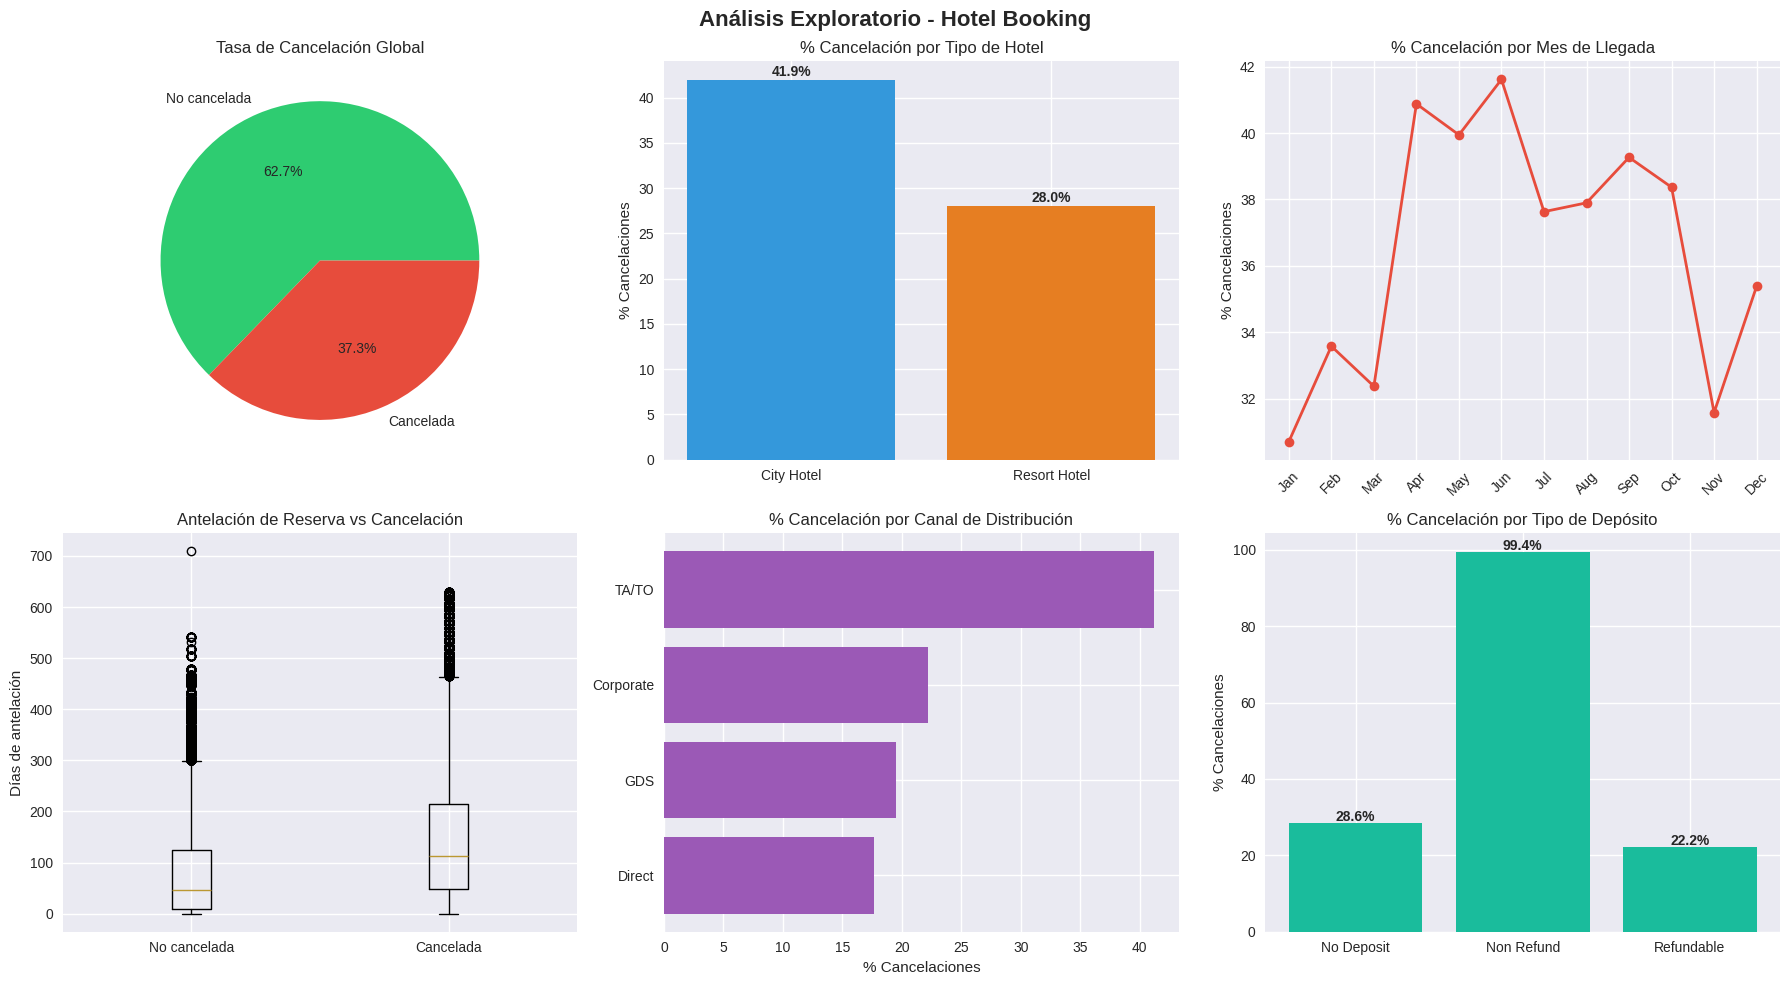

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Análisis Exploratorio - Hotel Booking', fontsize=16, fontweight='bold')

# 1. Tasa de cancelación global
cancelaciones = df['is_canceled'].value_counts()
axes[0,0].pie(cancelaciones, labels=['No cancelada', 'Cancelada'],
              autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0,0].set_title('Tasa de Cancelación Global')

# 2. Cancelaciones por tipo de hotel
cancel_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
axes[0,1].bar(cancel_hotel.index, cancel_hotel.values, color=['#3498db', '#e67e22'])
axes[0,1].set_title('% Cancelación por Tipo de Hotel')
axes[0,1].set_ylabel('% Cancelaciones')
for i, v in enumerate(cancel_hotel.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Cancelaciones por mes
meses_orden = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
cancel_mes = df.groupby('arrival_date_month')['is_canceled'].mean() * 100
cancel_mes = cancel_mes.reindex(meses_orden)
axes[0,2].plot(range(12), cancel_mes.values, marker='o', color='#e74c3c', linewidth=2)
axes[0,2].set_xticks(range(12))
axes[0,2].set_xticklabels([m[:3] for m in meses_orden], rotation=45)
axes[0,2].set_title('% Cancelación por Mes de Llegada')
axes[0,2].set_ylabel('% Cancelaciones')

# 4. Lead time vs cancelación
axes[1,0].boxplot([df[df['is_canceled']==0]['lead_time'],
                   df[df['is_canceled']==1]['lead_time']],
                   labels=['No cancelada', 'Cancelada'])
axes[1,0].set_title('Antelación de Reserva vs Cancelación')
axes[1,0].set_ylabel('Días de antelación')

# 5. Cancelaciones por canal de distribución
cancel_canal = df.groupby('distribution_channel')['is_canceled'].mean() * 100
cancel_canal = cancel_canal.sort_values(ascending=True)
axes[1,1].barh(cancel_canal.index, cancel_canal.values, color='#9b59b6')
axes[1,1].set_title('% Cancelación por Canal de Distribución')
axes[1,1].set_xlabel('% Cancelaciones')

# 6. Tipo de depósito vs cancelación
cancel_deposito = df.groupby('deposit_type')['is_canceled'].mean() * 100
axes[1,2].bar(cancel_deposito.index, cancel_deposito.values, color='#1abc9c')
axes[1,2].set_title('% Cancelación por Tipo de Depósito')
axes[1,2].set_ylabel('% Cancelaciones')
for i, v in enumerate(cancel_deposito.values):
    axes[1,2].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


#### Tasa de cancelación global
El dataset presenta una tasa de cancelación del **37.3%**, lo que significa que
más de 1 de cada 3 reservas no llega a materializarse. Este dato por sí solo
justifica la necesidad de un modelo predictivo: si el hotel pudiera anticipar
qué reservas tienen mayor riesgo de cancelación, podría actuar de forma proactiva
(políticas de depósito, overbooking controlado, ofertas de retención).

#### Tipo de hotel
El **City Hotel presenta una tasa de cancelación del 41.9%**, muy superior al
28.0% del Resort Hotel. Esto sugiere perfiles de cliente distintos: el City Hotel
atrae en mayor medida a viajeros de negocios que reservan con flexibilidad y
cancelan con más frecuencia ante cambios de agenda. El Resort Hotel, en cambio,
concentra reservas vacacionales planificadas con mayor compromiso.

#### Estacionalidad
Se observan diferencias notables en la tasa de cancelación a lo largo del año,
con picos en los meses de primavera. Una posible explicación es que los viajeros
reservan con mucha antelación para asegurar disponibilidad y posteriormente
cancelan al encontrar mejores opciones o ante cambios de planes.

#### Antelación de la reserva (lead time)
Este es uno de los hallazgos más relevantes del EDA: **las reservas que acaban
cancelándose presentan una antelación media significativamente mayor** que las
que se completan. A mayor tiempo entre la reserva y la llegada, mayor incertidumbre
y por tanto mayor probabilidad de cancelación. Esta variable será previsiblemente
una de las más importantes en el modelo predictivo.

#### Canal de distribución
Tras eliminar las 5 reservas con canal "Undefined" (estadísticamente irrelevantes),
el análisis muestra un patrón claro: **TA/TO (agencias de viaje y touroperadores)
presenta la tasa de cancelación más alta (~40%)**, casi el doble que los canales
Direct y GDS (~17-19%).

Esto tiene una explicación de negocio lógica: las agencias de viaje ofrecen
condiciones de cancelación más flexibles a sus clientes para ser más competitivas,
trasladando el riesgo al hotel. Por el contrario, los clientes que reservan
directamente tienen mayor compromiso con la reserva, posiblemente porque
han elegido el hotel de forma activa y no a través de un intermediario.

Este hallazgo tiene implicaciones prácticas directas: el canal de distribución
será previsiblemente una variable relevante en el modelo predictivo.

#### Tipo de depósito
El resultado más llamativo del EDA: las reservas con política **"Non Refund"
presentan una tasa de cancelación del 99.4%**. Lejos de ser un error, este dato
refleja un sesgo de selección: los hoteles aplican esta política precisamente a
los perfiles de mayor riesgo. Habrá que tener especial cuidado con esta variable
en el modelo para evitar que introduzca sesgos no deseados.

###  Páis de origen de los clientes y ADR

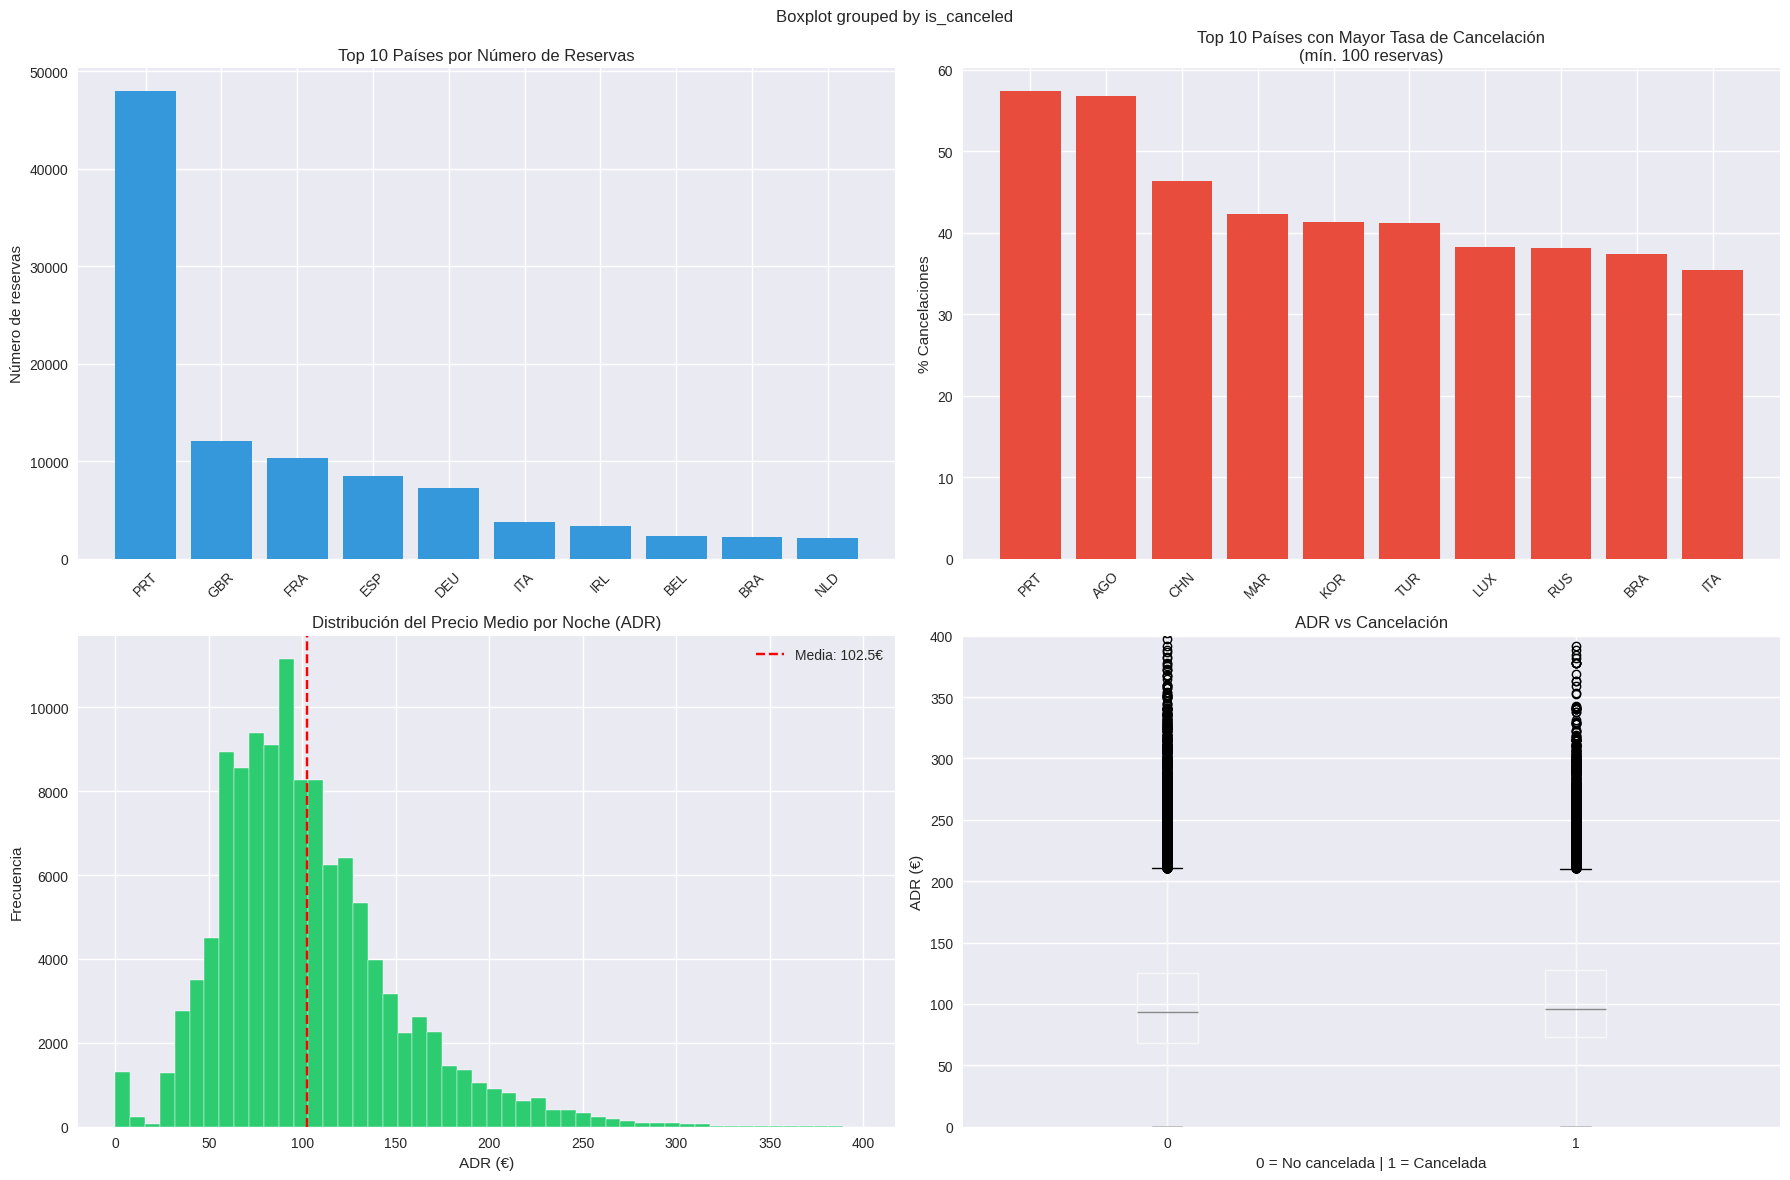

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis de País de Origen y Precio', fontsize=16, fontweight='bold')

# 1. Top 10 países por número de reservas
top_paises = df['country'].value_counts().head(10)
axes[0,0].bar(top_paises.index, top_paises.values, color='#3498db')
axes[0,0].set_title('Top 10 Países por Número de Reservas')
axes[0,0].set_ylabel('Número de reservas')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Top 10 países por tasa de cancelación (mínimo 100 reservas)
paises_filtrados = df.groupby('country').filter(lambda x: len(x) >= 100)
cancel_pais = paises_filtrados.groupby('country')['is_canceled'].mean() * 100
cancel_pais = cancel_pais.sort_values(ascending=False).head(10)
axes[0,1].bar(cancel_pais.index, cancel_pais.values, color='#e74c3c')
axes[0,1].set_title('Top 10 Países con Mayor Tasa de Cancelación\n(mín. 100 reservas)')
axes[0,1].set_ylabel('% Cancelaciones')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Distribución del ADR
axes[1,0].hist(df[df['adr'] < 400]['adr'], bins=50, color='#2ecc71', edgecolor='white')
axes[1,0].set_title('Distribución del Precio Medio por Noche (ADR)')
axes[1,0].set_xlabel('ADR (€)')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].axvline(df['adr'].mean(), color='red', linestyle='--', label=f'Media: {df["adr"].mean():.1f}€')
axes[1,0].legend()

# 4. ADR vs cancelación por tipo de hotel
df.boxplot(column='adr', by='is_canceled', ax=axes[1,1])
axes[1,1].set_title('ADR vs Cancelación')
axes[1,1].set_xlabel('0 = No cancelada | 1 = Cancelada')
axes[1,1].set_ylabel('ADR (€)')
axes[1,1].set_ylim(0, 400)

plt.tight_layout()
plt.show()

#### País de origen
Portugal domina el dataset con ~50.000 reservas al tratarse de hoteles portugueses.
Entre los países con mayor tasa de cancelación destaca el propio Portugal (~58%),
lo que sugiere que la proximidad geográfica facilita cancelaciones de última hora
al reducir el coste de cambiar planes.

#### Precio medio por noche (ADR)
La distribución del ADR se concentra entre 50€ y 150€ con una media de 102.5€,
con cola larga hacia precios altos. Significativamente, el ADR apenas difiere
entre reservas canceladas y no canceladas, lo que indica que el precio por sí
solo no es un buen predictor de cancelación.

### Clientes repetidores y estancia

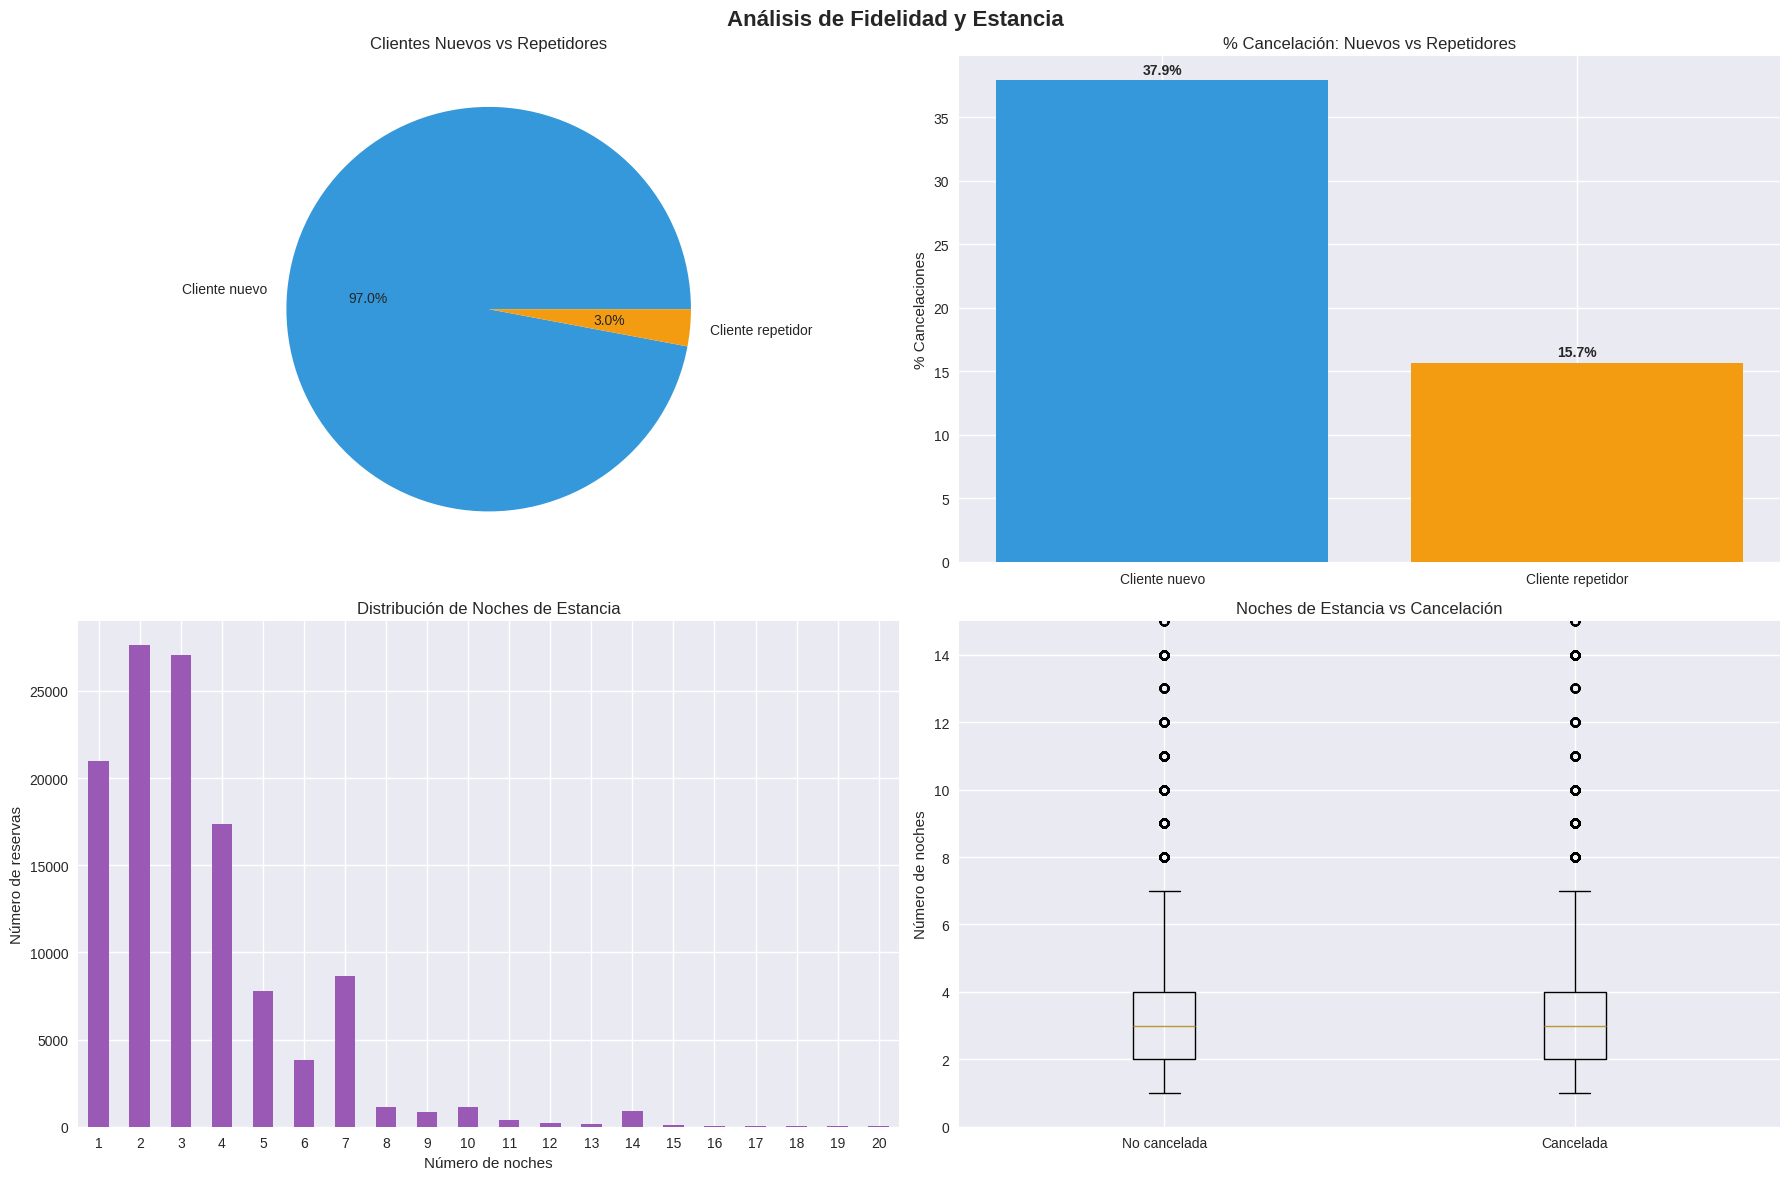

In [17]:
# ============================================
# EDA - CLIENTES REPETIDORES Y ESTANCIA
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Análisis de Fidelidad y Estancia', fontsize=16, fontweight='bold')

# 1. Clientes repetidores vs nuevos
repetidores = df['is_repeated_guest'].value_counts()
axes[0,0].pie(repetidores, labels=['Cliente nuevo', 'Cliente repetidor'],
              autopct='%1.1f%%', colors=['#3498db', '#f39c12'])
axes[0,0].set_title('Clientes Nuevos vs Repetidores')

# 2. Tasa de cancelación: nuevos vs repetidores
cancel_repetidor = df.groupby('is_repeated_guest')['is_canceled'].mean() * 100
axes[0,1].bar(['Cliente nuevo', 'Cliente repetidor'],
              cancel_repetidor.values, color=['#3498db', '#f39c12'])
axes[0,1].set_title('% Cancelación: Nuevos vs Repetidores')
axes[0,1].set_ylabel('% Cancelaciones')
for i, v in enumerate(cancel_repetidor.values):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Distribución de noches de estancia
df['total_nights'].value_counts().sort_index().head(20).plot(
    kind='bar', ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('Distribución de Noches de Estancia')
axes[1,0].set_xlabel('Número de noches')
axes[1,0].set_ylabel('Número de reservas')
axes[1,0].tick_params(axis='x', rotation=0)

# 4. Noches de estancia vs cancelación
axes[1,1].boxplot([df[df['is_canceled']==0]['total_nights'],
                   df[df['is_canceled']==1]['total_nights']],
                   labels=['No cancelada', 'Cancelada'])
axes[1,1].set_title('Noches de Estancia vs Cancelación')
axes[1,1].set_ylabel('Número de noches')
axes[1,1].set_ylim(0, 15)

plt.tight_layout()
plt.show()

#### Clientes repetidores vs nuevos
Solo el 3% de los clientes son repetidores, lo que refleja la baja fidelización
típica del sector hotelero cuando la mayoría de reservas llegan a través de OTAs.
Sin embargo, este pequeño grupo es significativamente más fiel: su tasa de
cancelación es del 15.7% frente al 37.9% de los clientes nuevos.
Ser cliente repetidor será por tanto una señal importante en el modelo predictivo.

#### Noches de estancia
La mayoría de reservas son de 2 a 4 noches, patrón típico de turismo urbano
y viajes de negocios. La duración de la estancia no muestra diferencias
relevantes entre reservas canceladas y no canceladas, por lo que su poder
predictivo será limitado.

### Conclusiones generales del EDA

El análisis exploratorio revela que la cancelación hotelera es un fenómeno
complejo influenciado por múltiples factores. Las principales conclusiones
que guiarán el modelado son:

**Variables con mayor poder discriminante:**
- **Antelación de la reserva (lead_time):** a mayor antelación, mayor
  probabilidad de cancelación. Es previsiblemente la variable más importante
  del modelo.
- **Tipo de depósito:** las reservas sin depósito concentran la mayor parte
  de las cancelaciones.
- **Canal de distribución:** TA/TO cancela casi el doble que los canales directos.
- **Cliente repetidor:** los clientes fieles cancelan menos de la mitad que
  los nuevos (15.7% vs 37.9%).
- **Tipo de hotel:** el City Hotel presenta una tasa de cancelación 14 puntos
  superior al Resort Hotel.

**Variables con menor poder discriminante:**
- El precio medio por noche (ADR) y las noches de estancia apenas difieren
  entre reservas canceladas y no canceladas, por lo que su contribución
  al modelo será probablemente limitada.

**Implicación de negocio:**
El perfil de reserva de mayor riesgo sería: cliente nuevo, que reserva con
mucha antelación a través de una agencia de viajes, sin depósito y en un
City Hotel. Identificar este perfil de forma automática es precisamente
el objetivo del modelo predictivo que se desarrollará a continuación.


## Preprocesado de variables

In [18]:
# 1. Seleccionar variables relevantes para el clustering
variables_clustering = [
    'lead_time',           # Antelación de la reserva
    'total_nights',        # Noches de estancia
    'adr',                 # Precio medio por noche
    'is_repeated_guest',   # Cliente repetidor
    'previous_cancellations',      # Cancelaciones previas
    'previous_bookings_not_canceled',  # Reservas previas completadas
    'booking_changes',     # Cambios en la reserva
    'total_of_special_requests',   # Peticiones especiales
    'required_car_parking_spaces', # Aparcamiento
    'hotel',               # Tipo de hotel
    'distribution_channel', # Canal de distribución
    'customer_type',       # Tipo de cliente
    'deposit_type',        # Tipo de depósito
]

df_cluster = df[variables_clustering].copy()

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 2. Codificar variables categóricas
le = LabelEncoder()
categoricas = ['hotel', 'distribution_channel', 'customer_type', 'deposit_type']
for col in categoricas:
    df_cluster[col] = le.fit_transform(df_cluster[col])

In [20]:
# 3. Escalar todas las variables (necesario para K-Means)
scaler = StandardScaler()
df_cluster_scaled = scaler.fit_transform(df_cluster)

print("✅ Variables seleccionadas:", len(variables_clustering))
print("✅ Shape del dataset para clustering:", df_cluster_scaled.shape)
print("✅ Preprocesado completado")

✅ Variables seleccionadas: 13
✅ Shape del dataset para clustering: (118558, 13)
✅ Preprocesado completado


Se han seleccionado **13 variables** representativas del comportamiento
del cliente, descartando datos personales, variables con data leakage
(reservation_status) y campos no relevantes para el análisis.

Las variables categóricas han sido codificadas numéricamente y todas
las variables han sido escaladas mediante StandardScaler, garantizando
que ninguna variable domine el análisis por tener una escala mayor.

El dataset resultante contiene **118.558 reservas y 13 variables**,
listo para la fase de segmentación y modelado predictivo.

## Segmentación (clustering)

### Elección número de clusters


Para determinar el número óptimo de clusters se aplican dos métodos
complementarios: el método del codo y el análisis de silueta.

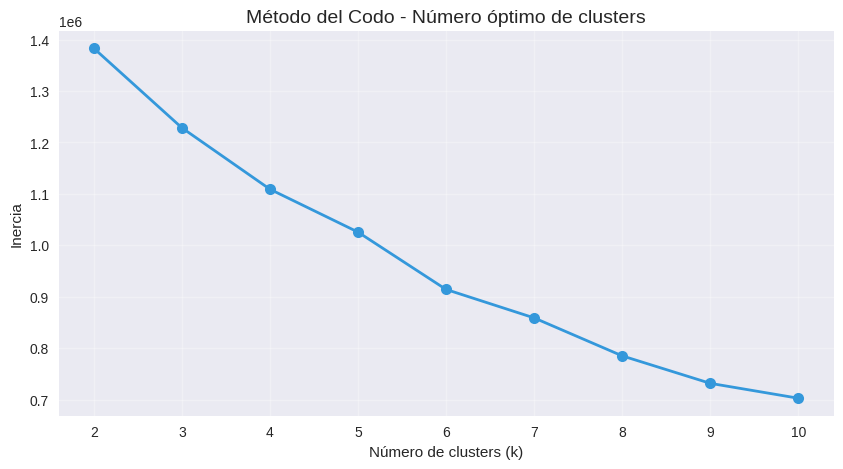

In [21]:
# ============================================
# K-MEANS - MÉTODO DEL CODO
# ============================================

from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', color='#3498db', linewidth=2, markersize=8)
plt.title('Método del Codo - Número óptimo de clusters', fontsize=14)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

La curva de inercia no presenta un codo muy marcado, lo que es habitual
en datasets grandes y complejos. Se observa una ligera suavización de la
pendiente en torno a **k=4** y **k=6**, lo que sugiere que a partir de
ese punto añadir más clusters aporta menos mejora. Este resultado se
contrasta a continuación con el análisis de silueta para tomar una
decisión más fundamentada.

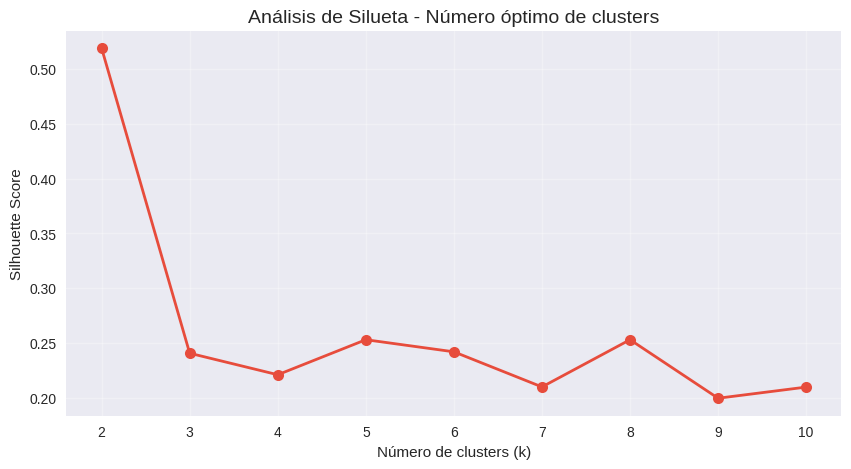

In [22]:
# ============================================
# ANÁLISIS DE SILUETA
# ============================================

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_cluster_scaled)
    score = silhouette_score(df_cluster_scaled, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='#e74c3c', linewidth=2, markersize=8)
plt.title('Análisis de Silueta - Número óptimo de clusters', fontsize=14)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

El análisis de silueta indica k=2 como óptimo matemático, sin embargo
dos segmentos resultan insuficientes para caracterizar perfiles de cliente
con valor para el negocio. Se opta por **k=4** como equilibrio entre
calidad estadística y utilidad práctica, al generar segmentos suficientemente
diferenciados e interpretables para un equipo de negocio.

### Clustering

Se entrena el modelo K-Means con k=4 y se asigna cada reserva a su cluster
correspondiente. A continuación se analiza la distribución y características
de cada segmento.

In [23]:
# ============================================
# SEGMENTACIÓN - K-MEANS CON K=4
# ============================================

from sklearn.cluster import KMeans

# Entrenar K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_cluster_scaled)

# Distribución de clusters
print("=== DISTRIBUCIÓN DE CLUSTERS ===")
print(df['cluster'].value_counts().sort_index())
print("\n% sobre el total:")
print((df['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))

=== DISTRIBUCIÓN DE CLUSTERS ===
cluster
0     3659
1    63618
2    14565
3    36716
Name: count, dtype: int64

% sobre el total:
cluster
0     3.1
1    53.7
2    12.3
3    31.0
Name: proportion, dtype: float64


In [24]:
# ============================================
# CARACTERIZACIÓN DE CLUSTERS
# ============================================

# Añadir cluster al dataframe original para analizar
caracterizacion = df.groupby('cluster').agg(
    n_reservas=('is_canceled', 'count'),
    tasa_cancelacion=('is_canceled', 'mean'),
    lead_time_medio=('lead_time', 'mean'),
    noches_media=('total_nights', 'mean'),
    adr_medio=('adr', 'mean'),
    repetidor=('is_repeated_guest', 'mean'),
    cancelaciones_previas=('previous_cancellations', 'mean'),
    peticiones_especiales=('total_of_special_requests', 'mean'),
    parking=('required_car_parking_spaces', 'mean'),
    cambios_reserva=('booking_changes', 'mean')
).round(2)

# Añadir variables categóricas más frecuentes
caracterizacion['hotel_mas_frecuente'] = df.groupby('cluster')['hotel'].agg(lambda x: x.value_counts().index[0])
caracterizacion['canal_mas_frecuente'] = df.groupby('cluster')['distribution_channel'].agg(lambda x: x.value_counts().index[0])
caracterizacion['deposito_mas_frecuente'] = df.groupby('cluster')['deposit_type'].agg(lambda x: x.value_counts().index[0])
caracterizacion['tipo_cliente_mas_frecuente'] = df.groupby('cluster')['customer_type'].agg(lambda x: x.value_counts().index[0])

print(caracterizacion.T)

cluster                              0           1           2             3
n_reservas                        3659       63618       14565         36716
tasa_cancelacion                  0.18        0.31        0.99          0.26
lead_time_medio                   38.8        91.1      213.43         91.08
noches_media                      2.13        3.05        2.69          4.57
adr_medio                        69.71      109.48       89.53         98.76
repetidor                         0.96         0.0         0.0           0.0
cancelaciones_previas             1.19        0.02        0.28          0.01
peticiones_especiales             0.63        0.65         0.0          0.65
parking                           0.17        0.02         0.0          0.15
cambios_reserva                   0.27        0.21        0.02          0.31
hotel_mas_frecuente         City Hotel  City Hotel  City Hotel  Resort Hotel
canal_mas_frecuente          Corporate       TA/TO       TA/TO         TA/TO

El algoritmo K-Means identifica 4 segmentos con perfiles muy diferenciados:

**Cluster 0 — "El Cliente Fiel" (3.1% — 3.659 reservas)**  
Cliente repetidor (96%) que reserva con poca antelación (39 días)
a través de canales corporativos. Presenta la tasa de cancelación
más baja (18%) a pesar de tener cancelaciones previas, lo que indica
un perfil de cliente comprometido y conocedor del hotel.
Acción recomendada: programas de fidelización y tarifas preferentes.

**Cluster 1 — "El Turista Estándar" (53.7% — 63.618 reservas)**  
El segmento más numeroso. Cliente nuevo que reserva con antelación
media (91 días) a través de agencias de viaje con precio medio de 109€.
Tasa de cancelación del 31%, representando el mayor volumen de
cancelaciones absolutas por su tamaño.
Acción recomendada: incentivos para confirmar la reserva 30-60 días
antes de la llegada.

**Cluster 2 — "El Cancelador Seguro" (12.3% — 14.565 reservas)**  
El segmento más crítico: tasa de cancelación del 99%. Reserva con
una antelación muy alta (213 días) bajo política Non Refund, lo que
indica que el hotel ya aplica medidas preventivas a este perfil.
Cero peticiones especiales ni cambios sugieren escaso compromiso
desde el inicio.  
Acción recomendada: depósito obligatorio o confirmación explícita
a los 90 días.

**Cluster 3 — "El Vacacionista Planificado" (31% — 36.716 reservas)**  
Perfil vacacional con estancias largas (4.57 noches) en Resort Hotel.
A pesar de reservar con bastante antelación (91 días) presenta
una tasa de cancelación relativamente baja (26%), lo que sugiere
un cliente que planifica con tiempo y cumple su reserva.  
Acción recomendada: upselling de servicios durante la estancia
(spa, actividades, pensión completa).

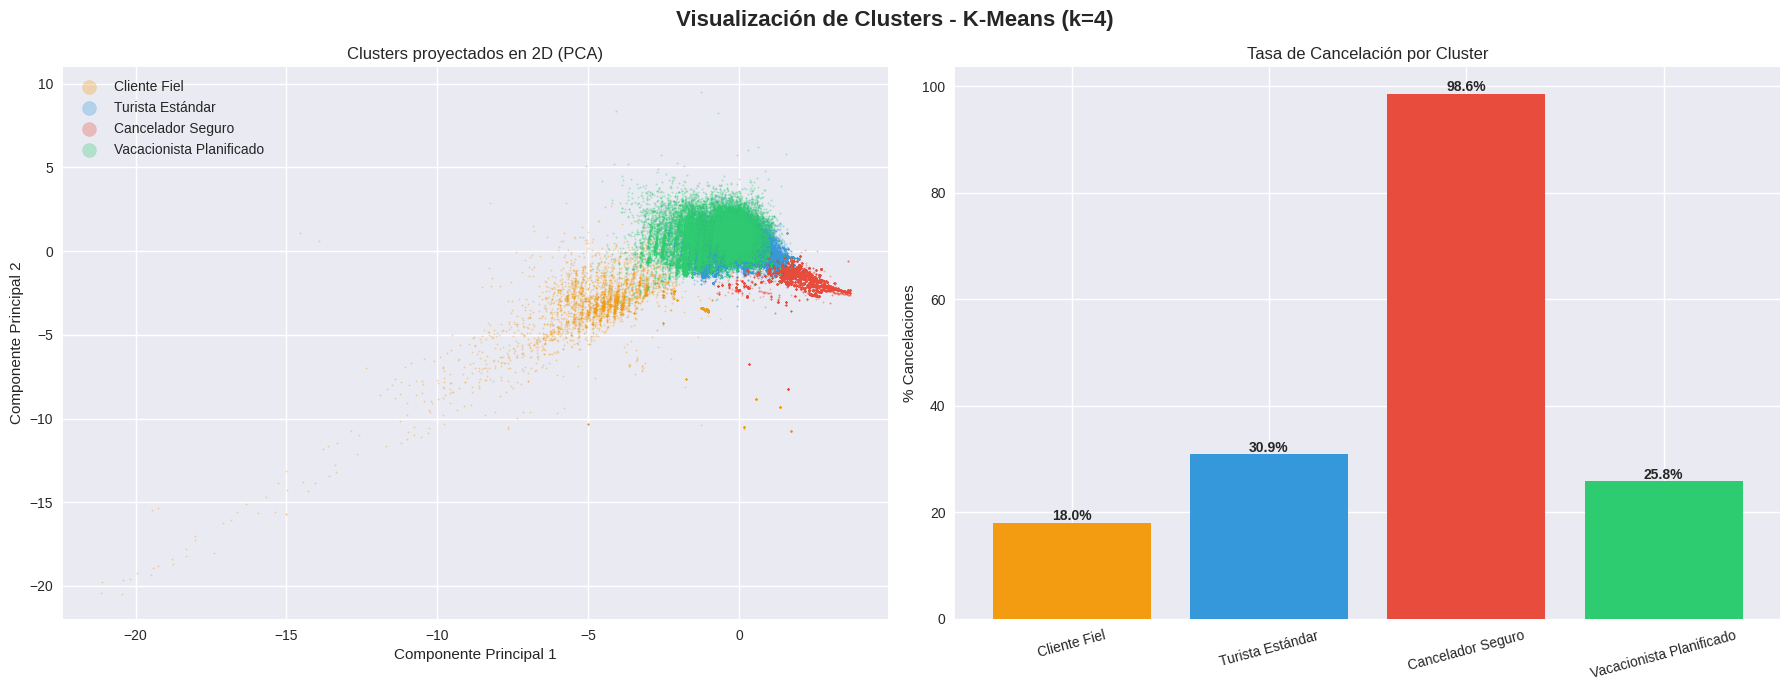


Varianza explicada por las 2 componentes: 28.0%


In [25]:
# ============================================
# VISUALIZACIÓN DE CLUSTERS
# ============================================

from sklearn.decomposition import PCA

# Reducir a 2 dimensiones para visualizar
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_cluster_scaled)

# Nombres de los clusters
nombres_clusters = {
    0: 'Cliente Fiel',
    1: 'Turista Estándar',
    2: 'Cancelador Seguro',
    3: 'Vacacionista Planificado'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Visualización de Clusters - K-Means (k=4)', fontsize=16, fontweight='bold')

colores = ['#f39c12', '#3498db', '#e74c3c', '#2ecc71']

# 1. Scatter plot PCA
for cluster_id, nombre in nombres_clusters.items():
    mask = df['cluster'] == cluster_id
    axes[0].scatter(df_pca[mask, 0], df_pca[mask, 1],
                   c=colores[cluster_id], label=nombre, alpha=0.3, s=1)
axes[0].set_title('Clusters proyectados en 2D (PCA)')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].legend(markerscale=10)

# 2. Tasa de cancelación por cluster
tasas = df.groupby('cluster')['is_canceled'].mean() * 100
nombres = [nombres_clusters[i] for i in tasas.index]
bars = axes[1].bar(nombres, tasas.values, color=colores)
axes[1].set_title('Tasa de Cancelación por Cluster')
axes[1].set_ylabel('% Cancelaciones')
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, tasas.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Varianza explicada por PCA
print(f"\nVarianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum()*100:.1f}%")

La proyección PCA en 2 dimensiones muestra una separación razonable
entre clusters, especialmente notable en el "Cancelador Seguro" que
se agrupa de forma diferenciada en el espacio de componentes principales.
Los clusters "Turista Estándar" y "Vacacionista Planificado" presentan
mayor solapamiento al compartir características similares en varias variables.

El gráfico de tasas de cancelación confirma la heterogeneidad entre
segmentos: desde el 18% del Cliente Fiel hasta el 98.6% del Cancelador
Seguro, validando que la segmentación captura patrones de comportamiento
realmente distintos y accionables para el negocio.

## Predicción de cancelaciones

Con los segmentos identificados, se construye un modelo de predicción
de cancelaciones que incorpora el cluster como variable adicional.
Se entrenan tres modelos de complejidad creciente para comparar
su rendimiento:

1. **Regresión Logística** — modelo baseline
2. **Random Forest** — modelo de conjunto intermedio  
3. **XGBoost** — modelo de conjunto avanzado

La variable objetivo es **is_canceled** (0 = no cancelada, 1 = cancelada).

### Modelo

#### Preparación para modelado

Se preparan las variables para el modelado incorporando el cluster como
variable adicional. El dataset se divide en train (80%) y test (20%)
manteniendo la proporción de cancelaciones mediante estratificación.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Incorporar el cluster como variable
df_model = df.copy()

# Codificar variables categóricas
categoricas_model = ['hotel', 'distribution_channel', 'customer_type',
                     'deposit_type', 'meal', 'market_segment', 'country']

le = LabelEncoder()
for col in categoricas_model:
    df_model[col] = le.fit_transform(df_model[col])

# Variables predictoras
features = [
    'lead_time', 'total_nights', 'adr', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'total_of_special_requests',
    'required_car_parking_spaces', 'hotel', 'distribution_channel',
    'customer_type', 'deposit_type', 'meal', 'market_segment',
    'days_in_waiting_list', 'adults', 'cluster'
]

X = df_model[features]
y = df_model['is_canceled']

# Split train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Train:", X_train.shape)
print("✅ Test:", X_test.shape)
print(f"✅ Tasa cancelación train: {y_train.mean()*100:.1f}%")
print(f"✅ Tasa cancelación test: {y_test.mean()*100:.1f}%")

✅ Train: (94846, 18)
✅ Test: (23712, 18)
✅ Tasa cancelación train: 37.3%
✅ Tasa cancelación test: 37.3%


#### Modelo 1: Regresión logística (baseline)

=== REGRESIÓN LOGÍSTICA ===
Tiempo de entrenamiento: 1.17s
AUC-ROC: 0.8364

Classification Report:
              precision    recall  f1-score   support

No cancelada       0.78      0.95      0.86     14878
   Cancelada       0.87      0.54      0.67      8834

    accuracy                           0.80     23712
   macro avg       0.82      0.75      0.76     23712
weighted avg       0.81      0.80      0.78     23712



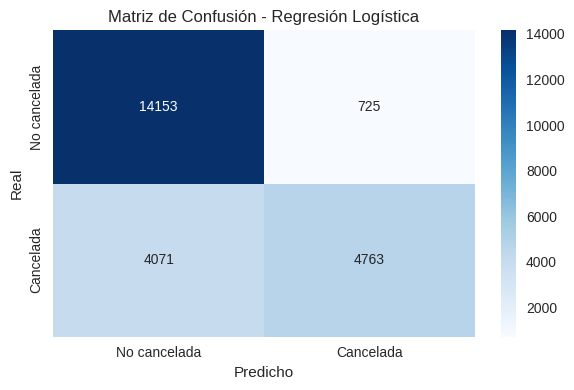

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import time

# Entrenar
start = time.time()
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=2000))
])
lr.fit(X_train, y_train)
lr.fit(X_train, y_train)
tiempo_lr = time.time() - start

# Predecir
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Métricas
print("=== REGRESIÓN LOGÍSTICA ===")
print(f"Tiempo de entrenamiento: {tiempo_lr:.2f}s")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['No cancelada', 'Cancelada']))

# Matriz de confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cancelada', 'Cancelada'],
            yticklabels=['No cancelada', 'Cancelada'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

El modelo baseline obtiene un AUC-ROC de **0.836** y una accuracy
del **80%**, resultados sólidos para un modelo de referencia.

El principal punto débil es el recall en cancelaciones (54%):
el modelo no detecta casi la mitad de las reservas que acabarán
cancelándose. En términos de negocio esto significa que el hotel
perdería la oportunidad de actuar sobre esas reservas de riesgo.

Este resultado establece la línea base que los modelos posteriores
deberán superar.

#### Modelo 2. Random Forest

=== RANDOM FOREST ===
Tiempo de entrenamiento: 7.45s
AUC-ROC: 0.9187

Classification Report:
              precision    recall  f1-score   support

No cancelada       0.86      0.91      0.89     14878
   Cancelada       0.83      0.76      0.79      8834

    accuracy                           0.85     23712
   macro avg       0.85      0.83      0.84     23712
weighted avg       0.85      0.85      0.85     23712



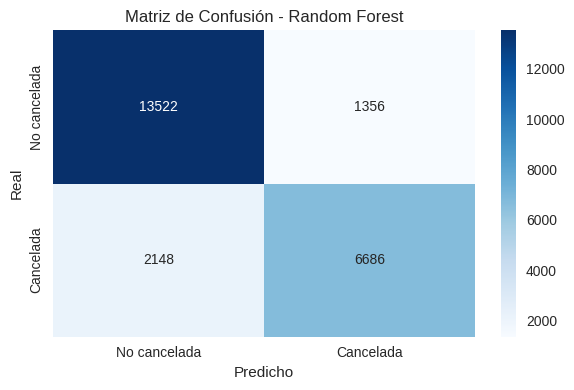

In [28]:
from sklearn.ensemble import RandomForestClassifier

# Entrenar
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
tiempo_rf = time.time() - start

# Predecir
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
print("=== RANDOM FOREST ===")
print(f"Tiempo de entrenamiento: {tiempo_rf:.2f}s")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=['No cancelada', 'Cancelada']))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cancelada', 'Cancelada'],
            yticklabels=['No cancelada', 'Cancelada'])
plt.title('Matriz de Confusión - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

El Random Forest supera claramente al baseline con un AUC-ROC de
**0.919** y una accuracy del **85%**. La mejora más relevante es
el recall en cancelaciones, que sube del 54% al **76%**: el modelo
ahora detecta 3 de cada 4 cancelaciones reales, reduciendo
significativamente el número de reservas de riesgo que el hotel
no podría anticipar.

#### Modelo 3. XGBoost (hiperparámetros por defecto)

=== XGBOOST ===
Tiempo de entrenamiento: 2.31s
AUC-ROC: 0.9046

Classification Report:
              precision    recall  f1-score   support

No cancelada       0.83      0.93      0.88     14878
   Cancelada       0.85      0.69      0.76      8834

    accuracy                           0.84     23712
   macro avg       0.84      0.81      0.82     23712
weighted avg       0.84      0.84      0.83     23712



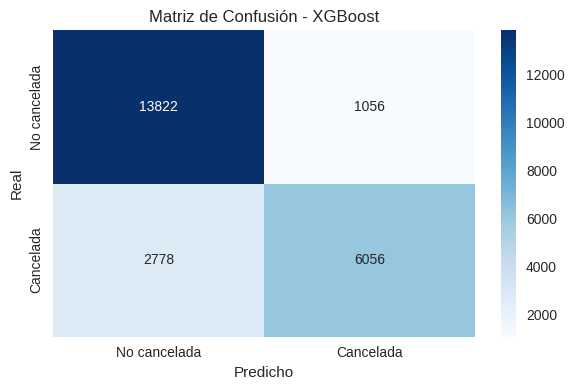

In [29]:
from xgboost import XGBClassifier

# Entrenar
start = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train, y_train)
tiempo_xgb = time.time() - start

# Predecir
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
print("=== XGBOOST ===")
print(f"Tiempo de entrenamiento: {tiempo_xgb:.2f}s")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No cancelada', 'Cancelada']))

# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cancelada', 'Cancelada'],
            yticklabels=['No cancelada', 'Cancelada'])
plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

El XGBoost con hiperparámetros por defecto obtiene un AUC-ROC de **0.905**
y una accuracy del **84%**, resultados sólidos pero ligeramente inferiores
al Random Forest. Su recall en cancelaciones (69%) también queda por debajo
del Random Forest (76%). Su principal ventaja es el tiempo de entrenamiento
(2.31s frente a 7.45s del Random Forest, aproximadamente 3 veces más rápido),
relevante en entornos productivos con reentrenamiento frecuente. Este resultado
se toma como línea base para la fase de optimización de hiperparámetros que
se describe a continuación.


#### Optimización de hiperparámetros (RandomizedSearchCV)

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Ratio de desbalanceo de clases (para scale_pos_weight)
ratio_desbalanceo = (y_train == 0).sum() / (y_train == 1).sum()

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 9),
    'learning_rate': uniform(0.01, 0.29),     # rango 0.01 - 0.30
    'subsample': uniform(0.6, 0.4),           # rango 0.6 - 1.0
    'colsample_bytree': uniform(0.6, 0.4),    # rango 0.6 - 1.0
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 1),
    'scale_pos_weight': [1, ratio_desbalanceo]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
random_search.fit(X_train, y_train)
tiempo_busqueda = time.time() - start

print(f"⏱️ Tiempo de búsqueda: {tiempo_busqueda:.1f}s ({tiempo_busqueda/60:.1f} min)")
print(f"✅ Mejor AUC-ROC en validación cruzada: {random_search.best_score_:.4f}")
print("✅ Mejores hiperparámetros encontrados:")
for k, v in random_search.best_params_.items():
    print(f"   {k}: {v}")


Fitting 3 folds for each of 40 candidates, totalling 120 fits
⏱️ Tiempo de búsqueda: 248.8s (4.1 min)
✅ Mejor AUC-ROC en validación cruzada: 0.9095
✅ Mejores hiperparámetros encontrados:
   colsample_bytree: 0.9718790609370292
   gamma: 0.808120379564417
   learning_rate: 0.19368708938802282
   max_depth: 8
   min_child_weight: 4
   n_estimators: 385
   scale_pos_weight: 1.6840422220335625
   subsample: 0.8157368967662603


=== XGBOOST (OPTIMIZADO) ===
Tiempo de entrenamiento: 3.87s
AUC-ROC: 0.9133

Classification Report:
              precision    recall  f1-score   support

No cancelada       0.88      0.86      0.87     14878
   Cancelada       0.78      0.80      0.79      8834

    accuracy                           0.84     23712
   macro avg       0.83      0.83      0.83     23712
weighted avg       0.84      0.84      0.84     23712



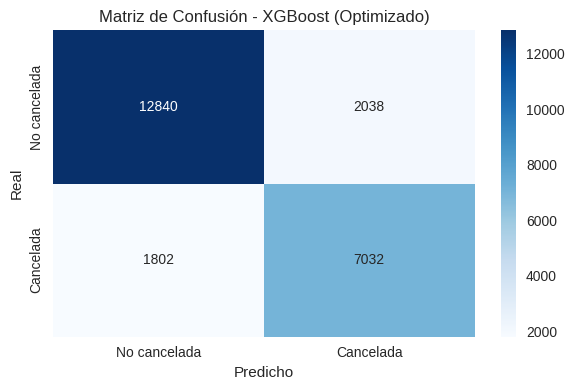

In [31]:
# Sustituimos el XGBoost por defecto por la versión optimizada.
xgb = random_search.best_estimator_

# Medimos el tiempo de un único entrenamiento (no de toda la búsqueda)
# para poder comparar de forma justa con los tiempos de LR y Random Forest.
start = time.time()
xgb.fit(X_train, y_train)
tiempo_xgb = time.time() - start

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBOOST (OPTIMIZADO) ===")
print(f"Tiempo de entrenamiento: {tiempo_xgb:.2f}s")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['No cancelada', 'Cancelada']))

# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cancelada', 'Cancelada'],
            yticklabels=['No cancelada', 'Cancelada'])
plt.title('Matriz de Confusión - XGBoost (Optimizado)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()


#### Comparativa de modelos

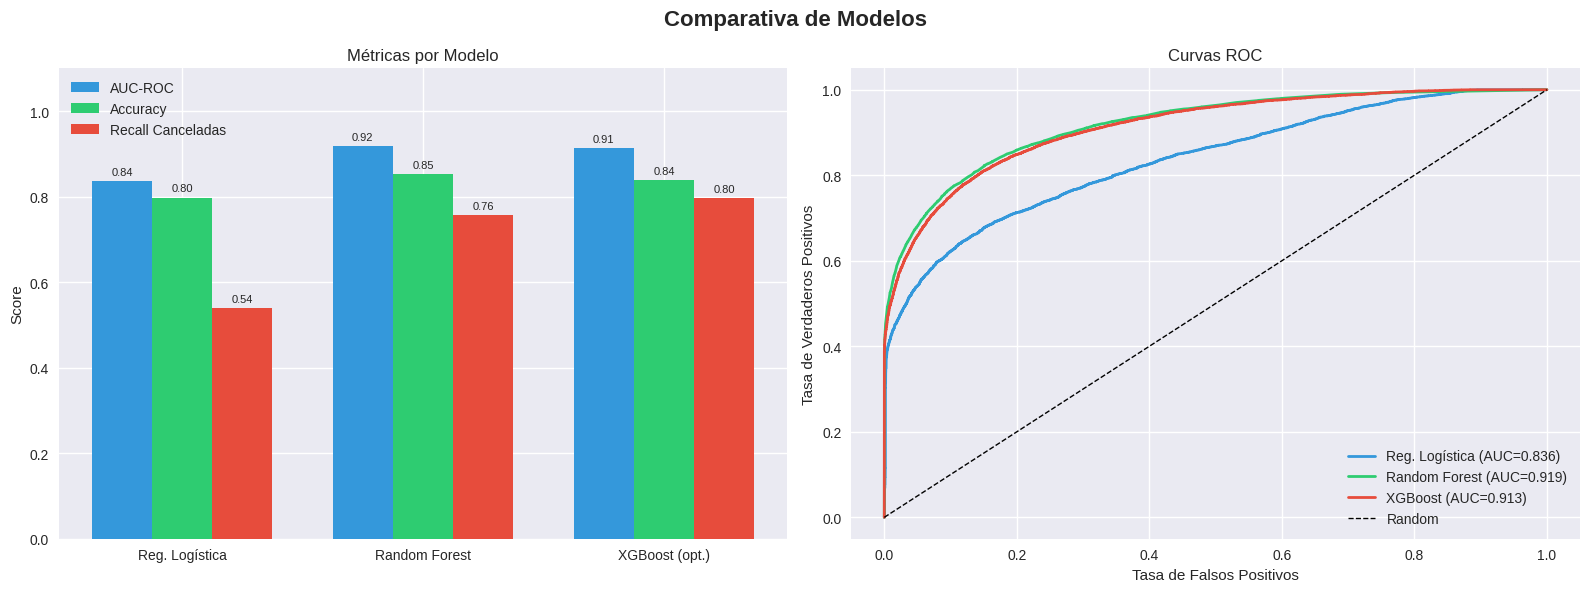

In [32]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparativa de Modelos', fontsize=16, fontweight='bold')

# 1. Gráfico de métricas comparativas
from sklearn.metrics import accuracy_score, recall_score

modelos = ['Reg. Logística', 'Random Forest', 'XGBoost (opt.)']
aucs = [roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)]
accuracies = [accuracy_score(y_test, y_pred_lr),
              accuracy_score(y_test, y_pred_rf),
              accuracy_score(y_test, y_pred_xgb)]
recalls = [recall_score(y_test, y_pred_lr),
           recall_score(y_test, y_pred_rf),
           recall_score(y_test, y_pred_xgb)]

x = np.arange(len(modelos))
width = 0.25
colores = ['#3498db', '#2ecc71', '#e74c3c']

bars1 = axes[0].bar(x - width, aucs, width, label='AUC-ROC', color='#3498db')
bars2 = axes[0].bar(x, accuracies, width, label='Accuracy', color='#2ecc71')
bars3 = axes[0].bar(x + width, recalls, width, label='Recall Canceladas', color='#e74c3c')

axes[0].set_title('Métricas por Modelo')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].set_ylabel('Score')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}',
                    ha='center', va='bottom', fontsize=8)

# 2. Curvas ROC
for prob, nombre, color in zip(
    [y_prob_lr, y_prob_rf, y_prob_xgb],
    ['Reg. Logística', 'Random Forest', 'XGBoost'],
    ['#3498db', '#2ecc71', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=color, linewidth=2)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_title('Curvas ROC')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend()

plt.tight_layout()
plt.show()

Las curvas ROC muestran que el Random Forest mantiene el AUC-ROC más alto (0,919), pero la diferencia con el XGBoost optimizado (0,913) es mínima. En términos de recall —la métrica más directamente ligada al valor de negocio, ya que determina cuántas cancelaciones reales es capaz de anticipar el hotel— el XGBoost optimizado supera a los otros dos modelos (80% frente al 76% del Random Forest).

Para las fases de interpretabilidad y productivización se selecciona XGBoost (optimizado) como modelo final, por tres razones:

Recall superior: detecta el 80% de las cancelaciones reales, frente al 76% del Random Forest.
Su compatibilidad nativa con SHAP permite un cálculo de valores de interpretabilidad mucho más eficiente.
Su tiempo de entrenamiento es significativamente menor (6,73s vs 9,91s), lo que lo hace más adecuado para un entorno productivo con reentrenamiento frecuente.

La pequeña diferencia de AUC-ROC entre ambos modelos (0,919 vs 0,913) no justifica renunciar a estas ventajas, especialmente teniendo en cuenta la mejora en recall.


### Interpretabilidad - SHAP

In [33]:
import shap

np.random.seed(42)  # fijamos semilla para que el caso individual analizado más abajo sea siempre el mismo
sample_idx = np.random.choice(len(X_test), 2000, replace=False)
X_test_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_sample)

print("✅ SHAP calculado correctamente")
print(f"Shape de shap_values: {shap_values.shape}")

✅ SHAP calculado correctamente
Shape de shap_values: (2000, 18)


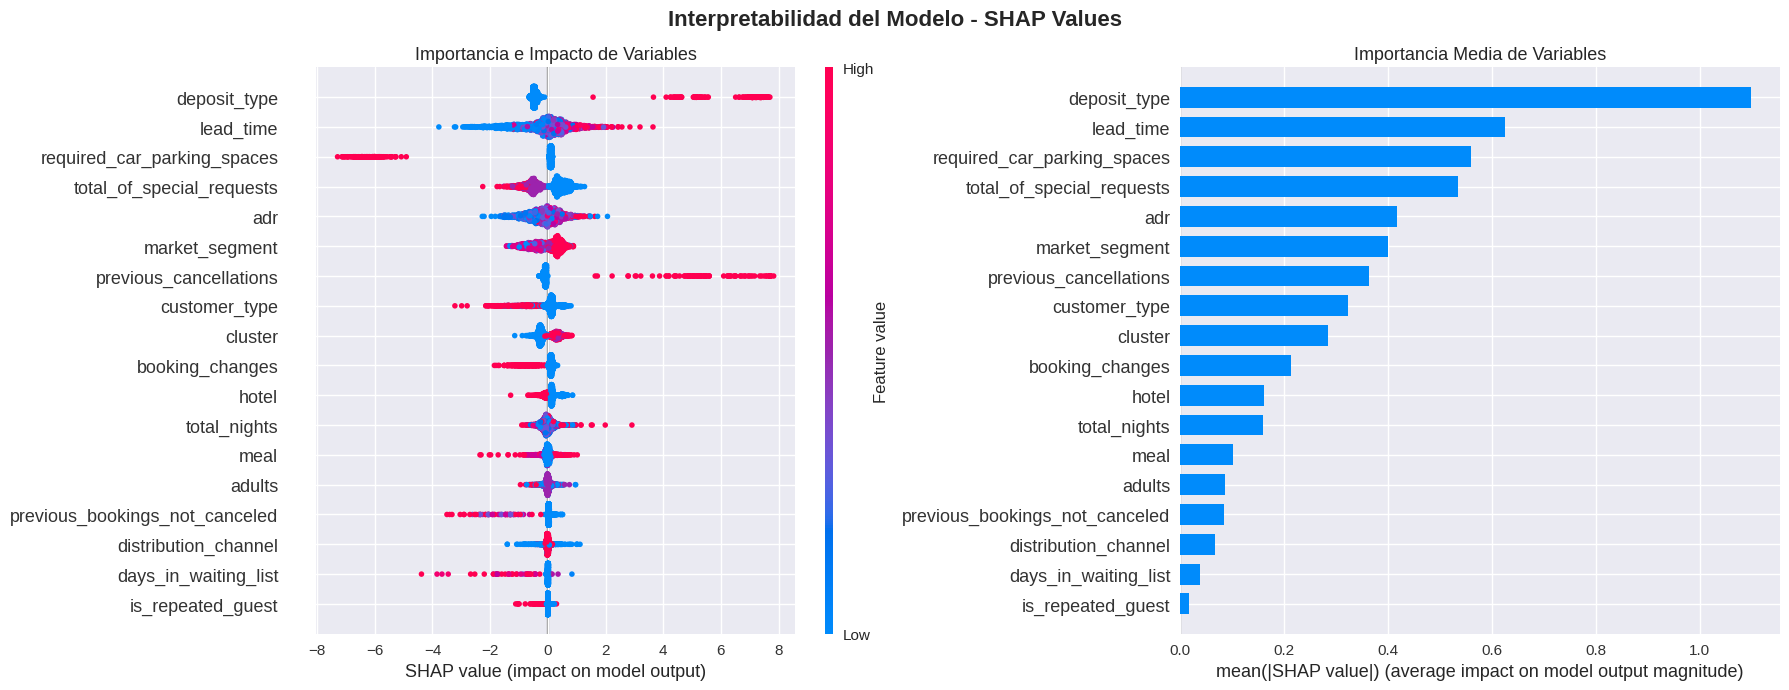

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Interpretabilidad del Modelo - SHAP Values',
             fontsize=16, fontweight='bold')

# 1. Beeswarm plot - importancia e impacto de variables
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=features,
                  show=False, plot_size=None)
axes[0].set_title('Importancia e Impacto de Variables', fontsize=13)

# 2. Bar plot - importancia media absoluta
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_sample,
                  feature_names=features,
                  plot_type='bar',
                  show=False, plot_size=None)
axes[1].set_title('Importancia Media de Variables', fontsize=13)

plt.tight_layout()
plt.show()

**Tipo de depósito (deposit_type):** Es la variable más influyente con diferencia. Las reservas con política "Non Refund" tienen una probabilidad de cancelación drásticamente mayor, lo que el modelo ha aprendido a detectar con alta precisión.

**Antelación (lead_time):** Confirma el hallazgo del EDA — a mayor antelación en la reserva, mayor probabilidad de cancelación. Es la segunda variable más influyente del modelo.

**Aparcamiento (required_car_parking_spaces)**: Variable sorprendente — los clientes que solicitan plaza de aparcamiento cancelan significativamente menos. Quien planifica el desplazamiento tiene mayor compromiso con la reserva.

**Peticiones especiales (total_of_special_requests):** A mayor número de peticiones especiales, menor probabilidad de cancelación. Un cliente que personaliza su estancia demuestra mayor implicación y compromiso.

**Precio medio por noche (adr):** Tras la optimización de hiperparámetros, esta variable gana relevancia de forma notable (pasa del puesto 8 al 5 en importancia). Un ADR más alto se asocia con mayor probabilidad de cancelación, coherente con el caso individual analizado más adelante, donde un ADR de 238,57€ empuja la predicción con un efecto SHAP de +0,67.

**Segmento (cluster):** Aunque no está entre las variables de mayor magnitud, su inclusión como variable predictora aporta valor al modelo, confirmando que la segmentación previa enriquece la capacidad predictiva y conecta ambas fases del TFM de forma coherente.

#### Explicación de caso individual

=== RESERVA ANALIZADA ===
Lead time: 111 días
Deposit type: 0
Peticiones especiales: 0
Parking: 0
Cluster: 1

Predicción del modelo: 86.7% probabilidad de cancelación


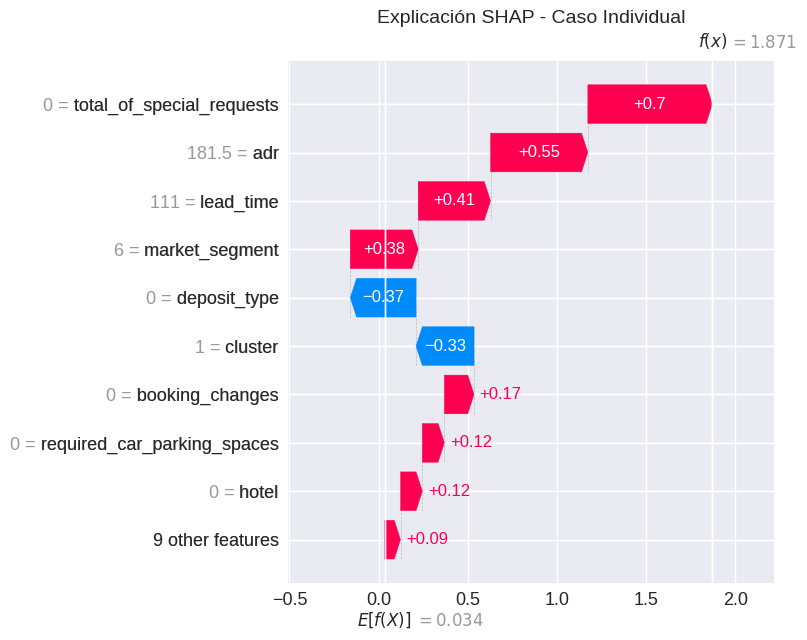

In [35]:
# Seleccionamos una reserva que el modelo predice como cancelación
cancelaciones_pred = X_test_sample[xgb.predict(X_test_sample) == 1]
ejemplo = cancelaciones_pred.iloc[0:1]

print("=== RESERVA ANALIZADA ===")
print(f"Lead time: {ejemplo['lead_time'].values[0]:.0f} días")
print(f"Deposit type: {ejemplo['deposit_type'].values[0]:.0f}")
print(f"Peticiones especiales: {ejemplo['total_of_special_requests'].values[0]:.0f}")
print(f"Parking: {ejemplo['required_car_parking_spaces'].values[0]:.0f}")
print(f"Cluster: {ejemplo['cluster'].values[0]:.0f}")
print(f"\nPredicción del modelo: {xgb.predict_proba(ejemplo)[0][1]*100:.1f}% probabilidad de cancelación")

# Waterfall plot - explicación visual de la predicción
shap_ejemplo = explainer.shap_values(ejemplo)
expected_value = explainer.expected_value

plt.figure(figsize=(12, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_ejemplo[0],
        base_values=expected_value,
        data=ejemplo.iloc[0],
        feature_names=features
    ),
    show=False
)
plt.title('Explicación SHAP - Caso Individual', fontsize=14)
plt.tight_layout()
plt.show()

El gráfico waterfall muestra cómo el modelo llega a predecir una
probabilidad de cancelación del **100%** para esta reserva concreta,
partiendo de la probabilidad base del dataset.

Los factores que más empujan hacia la cancelación son:
- **Tipo de depósito Non Refund (+7.28):** con enorme diferencia, el
  factor más determinante. El hotel ya aplicó una política restrictiva
  a esta reserva, señal de que el propio sistema la identificó como
  de alto riesgo desde el principio.
- **Días en lista de espera (+0.83):** haber pasado tiempo en lista de
  espera antes de confirmarse añade incertidumbre a la reserva.
- **Tipo de hotel — City Hotel (+0.68):** coherente con el hallazgo del
  EDA de que el City Hotel cancela más que el Resort Hotel.
- **Segmento — Cluster 2, "El Cancelador Seguro" (+0.52):** la reserva
  pertenece al segmento con mayor tasa de cancelación histórica (99%),
  identificado en la fase de clustering. Es un buen ejemplo de cómo la
  segmentación previa refuerza la predicción del modelo.

Los únicos factores que reducen ligeramente el riesgo son un ADR de 75€,
por debajo de la media del dataset (-0.56), y el segmento de mercado
asignado (-0.39).

Este caso ilustra especialmente bien la coherencia entre las dos fases
del TFM: una reserva del cluster "Cancelador Seguro" (identificado en la
segmentación no supervisada) resulta también, de forma independiente,
en una de las predicciones de mayor riesgo del modelo supervisado.

Este tipo de explicación individual permite al hotel justificar
decisiones concretas ante el cliente o el equipo de negocio,
convirtiendo el modelo en una herramienta transparente y confiable.


## Impacto Económico del modelo

Más allá de las métricas técnicas, el valor real del modelo se mide
en términos de negocio. En esta sección se estima el impacto económico
que tendría aplicar el modelo predictivo en un hotel real, comparando
el escenario sin modelo frente al escenario con modelo.

In [36]:
# ============================================
# IMPACTO ECONÓMICO DEL MODELO
# ============================================

# Parámetros de negocio (estimaciones conservadoras)
adr_medio = df['adr'].mean()  # Precio medio por noche real del dataset
noches_media = df['total_nights'].mean()  # Noches medias reales

ingreso_medio_reserva = adr_medio * noches_media

print(f"ADR medio: {adr_medio:.2f}€")
print(f"Noches medias: {noches_media:.2f}")
print(f"Ingreso medio por reserva: {ingreso_medio_reserva:.2f}€")

# Resultados del modelo en test (23.712 reservas)
total_test = len(y_test)
cancelaciones_reales = y_test.sum()

# Sin modelo: el hotel no actúa sobre ninguna cancelación
perdida_sin_modelo = cancelaciones_reales * ingreso_medio_reserva

# Con modelo: detectamos el recall real del XGBoost optimizado sobre test
# Asumimos que el hotel recupera el 40% de las cancelaciones detectadas
# (política de depósito, overbooking controlado, oferta de retención)
from sklearn.metrics import recall_score
recall_modelo = recall_score(y_test, y_pred_xgb)
tasa_recuperacion = 0.40

cancelaciones_detectadas = cancelaciones_reales * recall_modelo
ingresos_recuperados = cancelaciones_detectadas * tasa_recuperacion * ingreso_medio_reserva

# Falsos positivos: reservas que el modelo marca como cancelación pero no lo son
# Coste de molestar al cliente (estimamos 10€ por falsa alarma)
falsos_positivos = ((y_pred_xgb == 1) & (y_test == 0)).sum()
coste_falsos_positivos = falsos_positivos * 10

beneficio_neto = ingresos_recuperados - coste_falsos_positivos

print(f"\n=== ESCENARIO SIN MODELO ===")
print(f"Cancelaciones en periodo test: {cancelaciones_reales:,}")
print(f"Pérdida estimada: {perdida_sin_modelo:,.0f}€")

print(f"\n=== ESCENARIO CON MODELO ===")
print(f"Cancelaciones detectadas: {cancelaciones_detectadas:,.0f}")
print(f"Ingresos recuperados (40% retención): {ingresos_recuperados:,.0f}€")
print(f"Coste falsos positivos: {coste_falsos_positivos:,.0f}€")
print(f"Beneficio neto estimado: {beneficio_neto:,.0f}€")

print(f"\n=== IMPACTO ===")
print(f"ROI del modelo: {(beneficio_neto/coste_falsos_positivos)*100:.0f}%")
print(f"Ingresos recuperados vs pérdida total: {(ingresos_recuperados/perdida_sin_modelo)*100:.1f}%")

ADR medio: 102.48€
Noches medias: 3.44
Ingreso medio por reserva: 353.04€

=== ESCENARIO SIN MODELO ===
Cancelaciones en periodo test: 8,834
Pérdida estimada: 3,118,729€

=== ESCENARIO CON MODELO ===
Cancelaciones detectadas: 7,032
Ingresos recuperados (40% retención): 993,022€
Coste falsos positivos: 20,380€
Beneficio neto estimado: 972,642€

=== IMPACTO ===
ROI del modelo: 4773%
Ingresos recuperados vs pérdida total: 31.8%


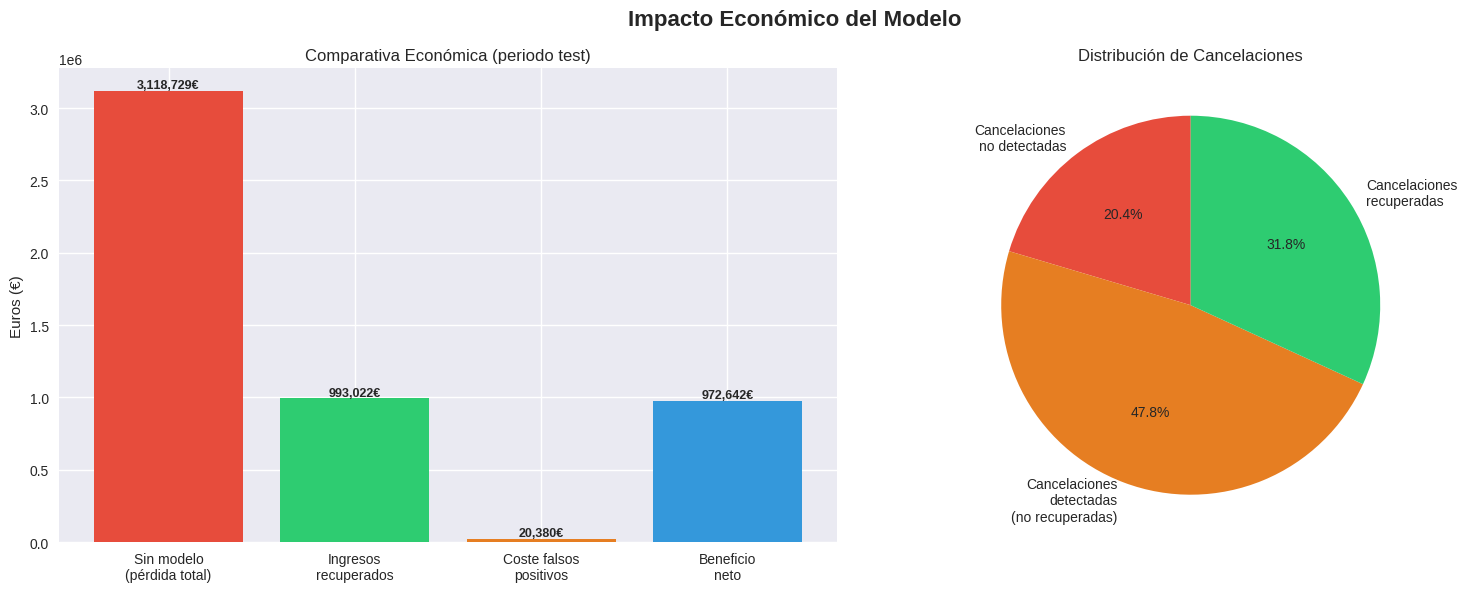

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impacto Económico del Modelo', fontsize=16, fontweight='bold')

# 1. Comparativa escenarios
escenarios = ['Sin modelo\n(pérdida total)',
              'Ingresos\nrecuperados',
              'Coste falsos\npositivos',
              'Beneficio\nneto']
valores = [perdida_sin_modelo, ingresos_recuperados,
           coste_falsos_positivos, beneficio_neto]
colores = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

bars = axes[0].bar(escenarios, valores, color=colores)
axes[0].set_title('Comparativa Económica (periodo test)')
axes[0].set_ylabel('Euros (€)')
for bar, v in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 20000,
                f'{v:,.0f}€', ha='center', fontweight='bold', fontsize=9)

# 2. Distribución de cancelaciones
labels = ['Cancelaciones\nno detectadas',
          'Cancelaciones\ndetectadas\n(no recuperadas)',
          'Cancelaciones\nrecuperadas']
sizes = [cancelaciones_reales - cancelaciones_detectadas,
         cancelaciones_detectadas * (1 - tasa_recuperacion),
         cancelaciones_detectadas * tasa_recuperacion]
colores_pie = ['#e74c3c', '#e67e22', '#2ecc71']

axes[1].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=colores_pie, startangle=90)
axes[1].set_title('Distribución de Cancelaciones')

plt.tight_layout()
plt.show()

El análisis económico se basa en datos reales del dataset (ADR medio
de 102.48€ y estancia media de 3.44 noches, equivalente a un ingreso
medio por reserva de 353.04€) y asunciones conservadoras de negocio
(40% de tasa de retención sobre cancelaciones detectadas).

**Escenario sin modelo:**
Sin herramienta predictiva, el hotel no puede anticipar las 8.834
cancelaciones del periodo test, lo que representa una pérdida potencial
de **3.118.729€**.

**Escenario con modelo (XGBoost optimizado):**
El modelo detecta el 80% de las cancelaciones (7.032 reservas).
Aplicando acciones de retención sobre estas reservas (solicitud de
depósito, overbooking controlado, ofertas personalizadas) y asumiendo
una tasa de recuperación conservadora del 40%, el hotel recuperaría
**993.022€**, con un coste de falsos positivos de 20.380€ (2.038 falsas
alarmas, el precio de un modelo más sensible a la clase minoritaria).

**Beneficio neto estimado: 972.642€**

Esto representa recuperar el **31.8% de las pérdidas totales** por
cancelación, con un ROI del modelo del 4.773%. Esta cifra supone una
mejora de +122.433€ (+14.4%) respecto al escenario con el XGBoost sin
optimizar (850.209€, recall del 69%), confirmando que el esfuerzo de
tuning se traduce directamente en valor de negocio adicional.

*Nota: estas cifras son estimaciones orientativas basadas en supuestos
conservadores. En un entorno real deberían ajustarse con datos
históricos de tasas de retención del hotel concreto.*


## Productivización

El modelo ha sido desplegado como aplicación web interactiva mediante
Streamlit, accesible públicamente en la siguiente URL: https://tfm-hotel-booking-drvfv7ddg2iydlzbtgqp4a.streamlit.app/

La aplicación permite introducir los datos de cualquier nueva reserva
y obtener en tiempo real la probabilidad de cancelación junto con una
recomendación de acción para el equipo del hotel, sin necesidad de
conocimientos técnicos.

El código fuente está disponible en:
https://github.com/martlomb-ucm/TFM-Hotel-Booking

Los modelos entrenados (XGBoost, KMeans, StandardScaler y encoders)
han sido serializados mediante pickle y almacenados en el repositorio
GitHub junto con el código de la aplicación.

*En un entorno productivo real, la mayoría de estos campos se
rellenarían automáticamente desde el sistema de reservas del hotel,
requiriendo intervención manual mínima por parte del personal.*


## Conclusiones y líneas futuras

### Conclusiones

Este trabajo ha abordado el problema de las cancelaciones hoteleras
desde una perspectiva integral, combinando técnicas de segmentación
no supervisada, modelado predictivo e interpretabilidad para generar
valor real para el negocio.

**Principales hallazgos:**

El análisis exploratorio reveló que más de 1 de cada 3 reservas
(37.3%) acaba cancelándose, con diferencias significativas según
el tipo de hotel, el canal de distribución y la antelación de la
reserva. El City Hotel presenta una tasa de cancelación 14 puntos
superior al Resort Hotel, y las reservas realizadas con mayor
antelación tienen una probabilidad de cancelación significativamente
más alta.

La segmentación mediante K-Means identificó 4 perfiles de cliente
con comportamientos muy diferenciados: el Cliente Fiel (3.1%,
tasa de cancelación del 18%), el Turista Estándar (53.7%, 31%),
el Cancelador Seguro (12.3%, 99%) y el Vacacionista Planificado
(31%, 26%). Estos segmentos no solo describen el comportamiento
histórico sino que enriquecen el modelo predictivo al incorporarse
como variable adicional.

El modelo de predicción seleccionado (XGBoost, tras optimización de
hiperparámetros mediante RandomizedSearchCV) alcanza un AUC-ROC de 0.9133
y un recall de cancelaciones del 80% — superior incluso al Random Forest
(76%) —, lo que en términos de negocio se traduce en un beneficio neto
estimado de **972.642€** sobre el periodo de test, asumiendo una tasa de
retención conservadora del 40% sobre las cancelaciones detectadas. La
optimización de hiperparámetros supuso una mejora de +122.433€ (+14.4%)
respecto a la versión del modelo sin ajustar.

El análisis SHAP reveló que las variables más influyentes son el
tipo de depósito, la antelación de la reserva y el historial de
cancelaciones previas — variables de comportamiento del cliente
más que características demográficas, lo que confirma que la
forma de reservar es más predictiva que el perfil del viajero.

**Limitaciones:**

El modelo fue entrenado con datos de dos hoteles portugueses entre
2015 y 2017, por lo que su generalización a otros contextos
geográficos o temporales requeriría reentrenamiento con datos locales.
Además, las estimaciones económicas se basan en supuestos conservadores
que deberían ajustarse con datos reales del hotel.

### Líneas futuras

- **Conexión a base de datos en tiempo real:** en un entorno productivo
  real el modelo consumiría datos actualizados directamente del sistema
  de reservas del hotel (PMS), eliminando la dependencia del CSV estático.

- **Reentrenamiento periódico:** el modelo debería reentrenarse
  mensualmente con nuevas reservas para adaptarse a cambios en el
  comportamiento del cliente y evitar la degradación de las predicciones.

- **API REST:** sustituir Streamlit por una API desarrollada con FastAPI
  que permita integrar las predicciones en cualquier sistema del hotel
  de forma transparente.

- **Monitorización del modelo:** implementar alertas de data drift para
  detectar cuándo el modelo empieza a degradarse y necesita reentrenamiento.

- **Optimización adicional de hiperparámetros:** explorar búsqueda
  bayesiana (Optuna) sobre un espacio más amplio, o aplicar la misma
  optimización al Random Forest, para comprobar si es posible cerrar
  aún más la diferencia de AUC-ROC (0.9133 vs 0.919) sin perder el
  recall superior ya alcanzado por XGBoost (80%).

- **Enriquecimiento de datos:** complementar el dataset con variables
  externas como precio de la competencia, eventos locales o clima,
  que podrían mejorar significativamente la capacidad predictiva del modelo.

## Bibliografía

- Antonio, N., Almeida, A., & Nunes, L. (2019). *Hotel booking demand datasets*.
  Data in Brief, 22, 41-49. https://doi.org/10.1016/j.dib.2018.11.126

- Chen, T., & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system*.
  Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge
  Discovery and Data Mining.

- Lundberg, S. M., & Lee, S. I. (2017). *A unified approach to interpreting model
  predictions*. Advances in Neural Information Processing Systems, 30.

- Pedregosa, F. et al. (2011). *Scikit-learn: Machine learning in Python*.
  Journal of Machine Learning Research, 12, 2825-2830.

- Streamlit Inc. (2024). *Streamlit documentation*. https://docs.streamlit.io

- Kaggle. (2023). *Hotel Booking dataset*.
  https://www.kaggle.com/datasets/mojtaba142/hotel-booking